In [ ]:
"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528 - Atmospheric Data Analysis
Assignment    : #01 - Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE - I.E., WHAT SPECIFIC THING IS BEING DONE]

"""
__author__    = "Jared W. Marquis"
__contact__   = "jared.marquis@und.edu"

In [1]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles


# F U im using pandas for reading the files cuz im LAZY
import pandas as pd

In [21]:
### Read in observations ###

# I think you'll have to change this if you're grading on a non-UNIX machine... sorry
observation_file = r"../RAOBs_201903131200.txt"


# This reads the data as comma-separated values, creating a pandas dataframe that is subsequently converted into a numpy array for easy manipulation later.
# Oh also it has no headers, which also makes things easier later.
observations = pd.read_csv(observation_file, header=None).to_numpy()

print(observations[:,2])

[-90.2 -66.0 -113.9 -73.6 -96.0 -105.1 -85.8 -133.4 -68.5 -58.5 -62.2
 -80.6 -78.0 -101.1 -94.9 -60.0 -111.9 -81.2 -68.4 -126.8 -122.5 -94.0
 -60.4 -127.3 -66.2 -122.8 -106.6 -98.4 -152.4 -79.9 -156.6 -103.2 -72.2
 -101.7 -150.0 -131.5 -82.4 -93.6 -161.8 -100.7 -85.2 -86.6 -116.2 -97.4
 -156.7 -78.7 -89.9 -68.0 -162.7 -69.96 -80.0 -97.5 -99.9 -104.7 -100.7
 -110.8 -104.8 -100.9 -83.4 -90.5 -106.7 -81.7 -147.8 -84.5 -111.8 -95.6
 -96.7 -106.6 -108.5 -88.1 -79.9 -70.26 -77.4 -83.8 -88.6 -93.3 -155.0
 -90.0 -81.7 -66.0 -61.3 -100.6 -93.2 -92.2 -114.2 -92.2 -102.2 -99.0
 -79.6 -122.8 -76.88 -80.2 -93.55 -106.4 -97.2 -81.6 -117.1 -81.6 -118.59
 -122.2 -95.6 -97.6 -72.86 -165.4 -116.4 -162.6 -97.4 -89.6 -80.2 -103.0
 -118.2 -108.4 -75.4 -79.5 -84.2 -69.8 -93.3 -93.8 -89.7 -111.9 -123.0
 -170.22 -82.4 -110.6 -84.3 -95.6 -110.9 -124.5 -102.8 -115.18 -75.4 -64.6
 -139.6 -75.9 -135.0]


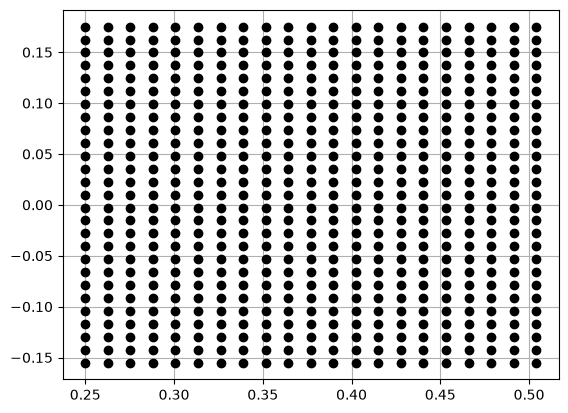

In [78]:
### Set up analysis map with a 21x27 rectangular grid of points ###
''' We have a polar stereographic projection with a standard latitude of 60degN and a standard latitude of 100degW. Map scale is 1/15,000,000. 
    We need our origin at 90degN latitude and 0deg longitude, with grid points every 1.27cm extending to x = +- 25cm and y = +- 15.5cm.
    The first array member (0,0) is supposed to be at x = 25cm, y = -15.5cm.
'''

#np array element format: array[col][row], both starting at zero

# Init lists of x- & y-values
x = []
y = []

# x- & y-values at (0,0)
x0 = .25
y0 = -.155

# Populating the x & y lists with all the values on the grid
# You will note that all cm values have been converted to m
for i in range(27):
    diff = i * .0127
    if(i < 21):
        x.append(x0 + diff)
    else:
        x.append(np.nan)
    y.append(y0 + diff)

cartesianPoints = np.array([x, y])

# Use the x- & y-values to populate two new numpy arrays with the values necessary to actually graph all gridpoints
gridx, gridy = np.meshgrid(x,y)

# Plot the grid of values, to assure that we made it correctly
fig, ax = plt.subplots()
ax.plot(gridx, gridy, marker='o', color='k', linestyle='none')
ax.grid()
plt.show()



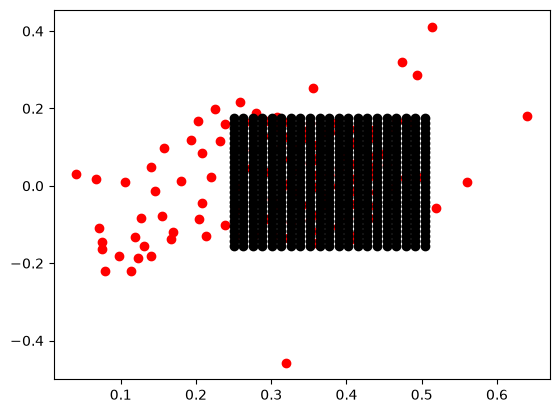

In [45]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###

# Conversion factor we need cuz numpy trig fcns are in radians
degToRad = np.pi / 180

# Defining our standard latitude & longitude
standardLat = 60 * degToRad
standardLong = -100 * degToRad

# Earth's mean radius, in meters
rho = 6.371e6

# Map scale
m = 1 / 15e6

# Helper function for calculating scale factor
def __scaleFactor__(lat: float) -> float:
    sigmaNumerator = 1 + np.sin(standardLat)
    sigmaDenominator = 1 + np.sin(lat)

    return (sigmaNumerator / sigmaDenominator)

# Defining a function to convert from lat/long to x/y
def getCartesian(latDeg: float, longDeg: float) -> float:
    lat = latDeg * degToRad
    long = (longDeg * degToRad) - standardLong
    sigma = __scaleFactor__(lat)
    r = m * rho * sigma * np.cos(lat)
    x = r * np.cos(long)
    y = r * np.sin(long)

    return x,y



# Initializing lists for the x- & y-values we will calculate from the observation lat/long
obsx = []
obsy = []

for i in range(observations.shape[0]):
    tempx, tempy = getCartesian(observations[i][1], observations[i][2])
    obsx.append(tempx)
    obsy.append(tempy)


fig, ax = plt.subplots()
ax.plot(obsx, obsy, marker='o', color='r', linestyle='none')
ax.plot(gridx, gridy, marker='o', color='k', linestyle='none')
plt.show()


In [ ]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm) ###


NameError: name 'ANALYSIS' is not defined

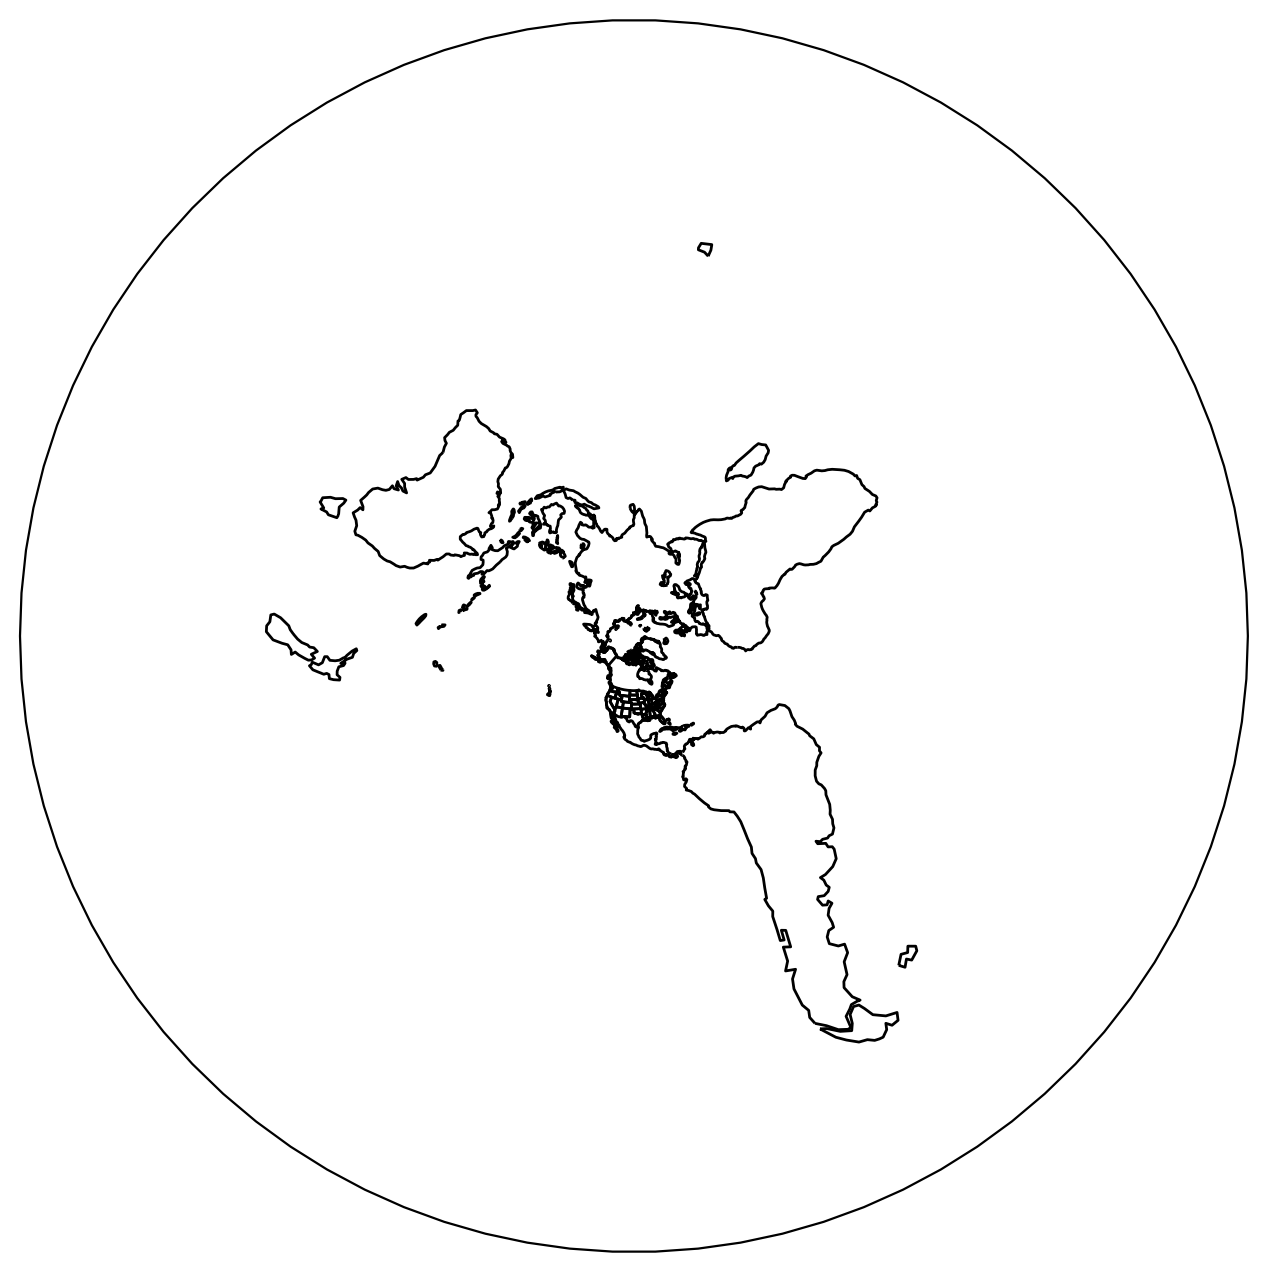

In [81]:
import os
os.environ["PROJ_IGNORE_CELESTIAL_BODY"] = "YES"
### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=-100,central_latitude=90,true_scale_latitude=60,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(gridy/m/100,-gridx/m/100,ANALYSIS[:,:,0],colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))

plt.show()

In [ ]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=-100,central_latitude=90,true_scale_latitude=60,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(Y/m/100,-X/m/100,N_OBS[:,:,0],colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))

plt.show()

TypeError: unsupported operand type(s) for /: 'list' and 'float'

Error in callback <function _draw_all_if_interactive at 0x76e88f476f20> (for post_execute), with arguments args (),kwargs {}:


ProjError: Error creating Transformer from CRS.: (Internal Proj Error: proj_create_operations: Source and target ellipsoid do not belong to the same celestial body (Earth vs Non-Earth body). You may override this check by setting the PROJ_IGNORE_CELESTIAL_BODY environment variable to YES.)

ProjError: Error creating Transformer from CRS.: (Internal Proj Error: proj_create_operations: Source and target ellipsoid do not belong to the same celestial body (Earth vs Non-Earth body). You may override this check by setting the PROJ_IGNORE_CELESTIAL_BODY environment variable to YES.)

<Figure size 1600x1600 with 1 Axes>

In [ ]:
### Store the analyses in text files ###



In [ ]:
### Store the number of observations available for each grid point in text files ###



In [ ]:
### In a separte text file (or below), answer the following questions ###
'''
1 - Describe the general features that you see in your contoured analyses.
    

2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?
    

3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?
    

4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?
    

'''